For Fig. 3D, E and Fig. S5A

In [1]:
suppressPackageStartupMessages({
library(ggplot2)
library(stringr)
library(Seurat)
library(dplyr)
library(showtext)
library(sysfonts)

# Download Roboto from Google Font, which is same as in Biorender
font_add_google("Roboto", "roboto")

# Enable showtext rendering
showtext_auto()

# Optional: set a default theme with Roboto for all plots
theme_set(theme_grey(base_family = "roboto") +
          theme( text = element_text(color = "black"))
          )
})
set.seed(100)

In [2]:
#load file
WD <- "data/"
sample <- "filtered_counts_NRF2_full.rds"

adata <- readRDS(paste0(WD, sample))
adata

An object of class Seurat 
28462 features across 162 samples within 1 assay 
Active assay: RNA (28462 features, 0 variable features)
 1 layer present: counts

In [3]:
#remove NFE2L2 because its expression is likely affected by additional primers.
x <- c('NFE2L2')
adata <- subset(adata,features=setdiff(rownames(adata),x))
adata

An object of class Seurat 
28461 features across 162 samples within 1 assay 
Active assay: RNA (28461 features, 0 variable features)
 1 layer present: counts

In [4]:
#change names
adata$sample_group[adata$sample_group == "WT from edited pool"] <- "WT"
adata$sample_group[adata$sample_group == "NRF2 T80K from edited pool"] <- "T80K"
adata$sample_group[adata$sample_group == "negative control"] <- "non-targeting"
table(adata@meta.data$sample_group)


         T80K            WT non-targeting  untransduced 
           43            40            44            35 

In [5]:
#Normalise
adata <- NormalizeData(adata)

Normalizing layer: counts



Finding variable features for layer counts

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.2329”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.50049”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  9.3746e-16”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.090619”
When using repel, set xnudge and ynudge to 0 for optimal results

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


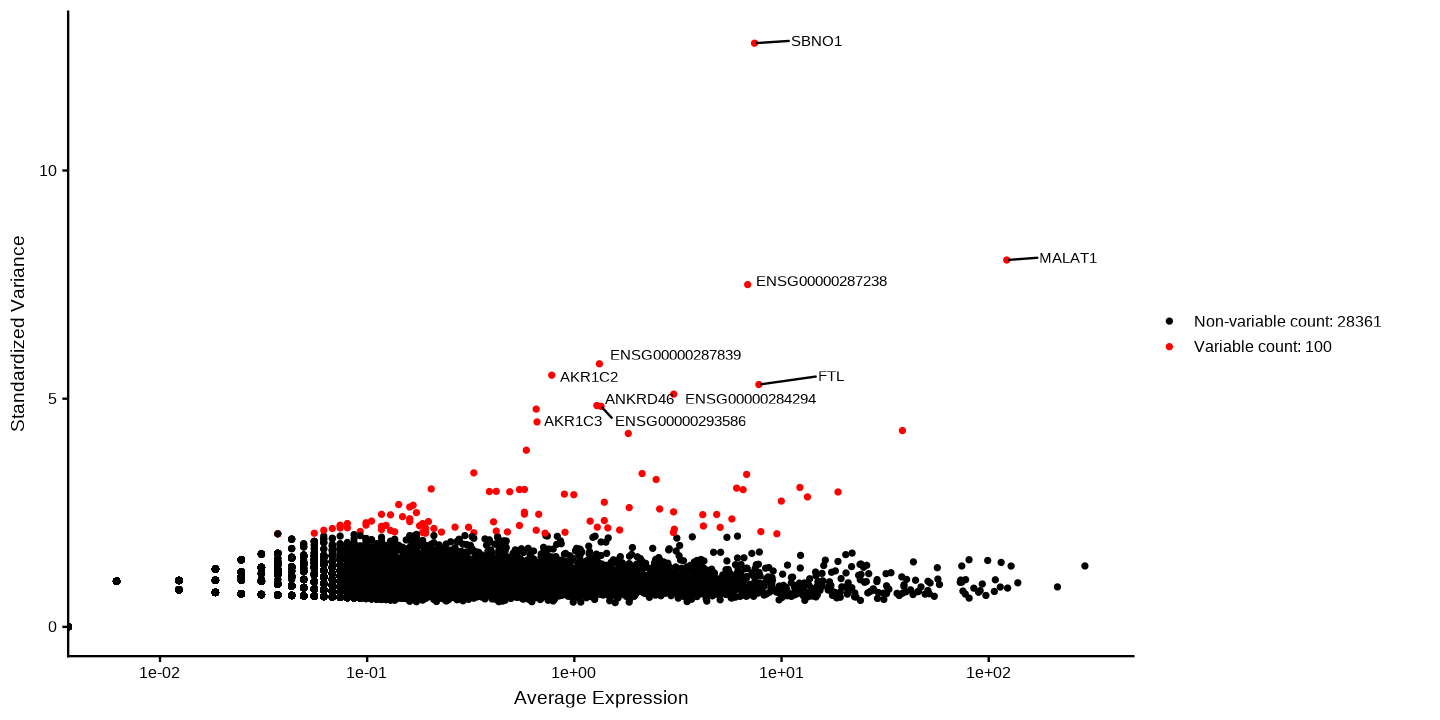

In [6]:
options(repr.plot.width = 12, repr.plot.height =6) 
adata <- FindVariableFeatures(adata, selection.method = "vst", nfeatures = 100)

# Identify the 10 most highly variable genes
top10 <- head(VariableFeatures(adata), 10)

# plot variable features
plot1 <- VariableFeaturePlot(adata)
plot2 <- LabelPoints(plot = plot1, points = top10, repel = TRUE)
plot2

In [7]:
adata <- ScaleData(adata)
adata <- RunPCA(adata, features = VariableFeatures(object = adata))

Centering and scaling data matrix

Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
PC_ 1 
Positive:  ITM2A, ANXA1, POU5F1, RIMS2, PSMA3, PNPT1, PCDH9, CKS2, DYNC1I1, SBNO1 
	   ENSG00000289358, CCNB1, HMGB1P1, ENSG00000286899, ADAMTS2, ZDHHC9, RBMS3-AS3, ENSG00000293132, POLD1, SOX2 
	   NSG1, MRNIP-DT, PHKG1, AKR1C1, VAMP8, LINC01063, CABIN1, TNFRSF1A, ACTL8, TSEN34 
Negative:  ENSG00000284294, ENSG00000287839, ENSG00000287238, ENSG00000293586, ENSG00000230309, GSTP1, ENSG00000293573, ENSG00000293268, TMSB4X, NEAT1 
	   MALAT1, FTL, FTH1, TULP2, SLC3A2, NTAN1, MKNK2, PCDH17, DDIT3, FOS 
	   NUPR1, KLRK1-AS1, NQO1, ENSG00000286871, HDHD3, TRPV2, UBC, XACT, ENSG00000251417, POLDIP2 
PC_ 2 
Positive:  AKR1C1, AKR1C3, AKR1C2, FTL, NQO1, PIR, FTH1, UCHL1, NUPR1, GSTP1 
	   SLC3A2, POU5F1, GPAM, TNFRSF1A, ANXA1, MLLT11, CD36, KCMF1, NTAN1, DOP1B 
	   CCNB1, CKS2, PSMA3, ENSG00

In [8]:
# Examine and visualize PCA results
print(adata[["pca"]], dims = 1:10)

PC_ 1 
Positive:  ITM2A, ANXA1, POU5F1, RIMS2, PSMA3, PNPT1, PCDH9, CKS2, DYNC1I1, SBNO1 
	   ENSG00000289358, CCNB1, HMGB1P1, ENSG00000286899, ADAMTS2, ZDHHC9, RBMS3-AS3, ENSG00000293132, POLD1, SOX2 
Negative:  ENSG00000284294, ENSG00000287839, ENSG00000287238, ENSG00000293586, ENSG00000230309, GSTP1, ENSG00000293573, ENSG00000293268, TMSB4X, NEAT1 
	   MALAT1, FTL, FTH1, TULP2, SLC3A2, NTAN1, MKNK2, PCDH17, DDIT3, FOS 
PC_ 2 
Positive:  AKR1C1, AKR1C3, AKR1C2, FTL, NQO1, PIR, FTH1, UCHL1, NUPR1, GSTP1 
	   SLC3A2, POU5F1, GPAM, TNFRSF1A, ANXA1, MLLT11, CD36, KCMF1, NTAN1, DOP1B 
Negative:  NEAT1, ENSG00000234426, ENSG00000293573, ENSG00000286899, ANKRD46, ENSG00000286871, A1BG, ENSG00000287238, TRPV2, ENSG00000293586 
	   ENSG00000289915, IFT81, ENSG00000287839, FOS, H4C3, U2AF1L4, PCDH9, EFNA3, DYNC1I1, ENOX2 
PC_ 3 
Positive:  ENSG00000286871, MRNIP-DT, NQO1, H4C3, FOS, HSPA8, FTH1, TSEN34, ANKRD46, ENOX2 
	   ZDHHC9, XACT, UCHL1, PIR, POLD1, ENSG00000290032, ACTL8, ENSG0000029313

In [9]:
adata <- FindNeighbors(adata, dims = 1:10, reduction = "pca")
adata <- FindClusters(adata, resolution = 2, cluster.name = "unintegrated_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 162
Number of edges: 6968

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.1110
Number of communities: 18
Elapsed time: 0 seconds


5 singletons identified. 13 final clusters.



Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
17:02:35 UMAP embedding parameters a = 0.9922 b = 1.112

17:02:35 Read 162 rows and found 10 numeric columns

17:02:35 Using Annoy for neighbor search, n_neighbors = 30

17:02:35 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:02:35 Writing NN index file to temp file /tmp/RtmpkLwLIi/file9c8871c5be065

17:02:35 Searching Annoy index using 1 thread, search_k = 3000

17:02:35 Annoy recall = 100%

17:02:36 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors =

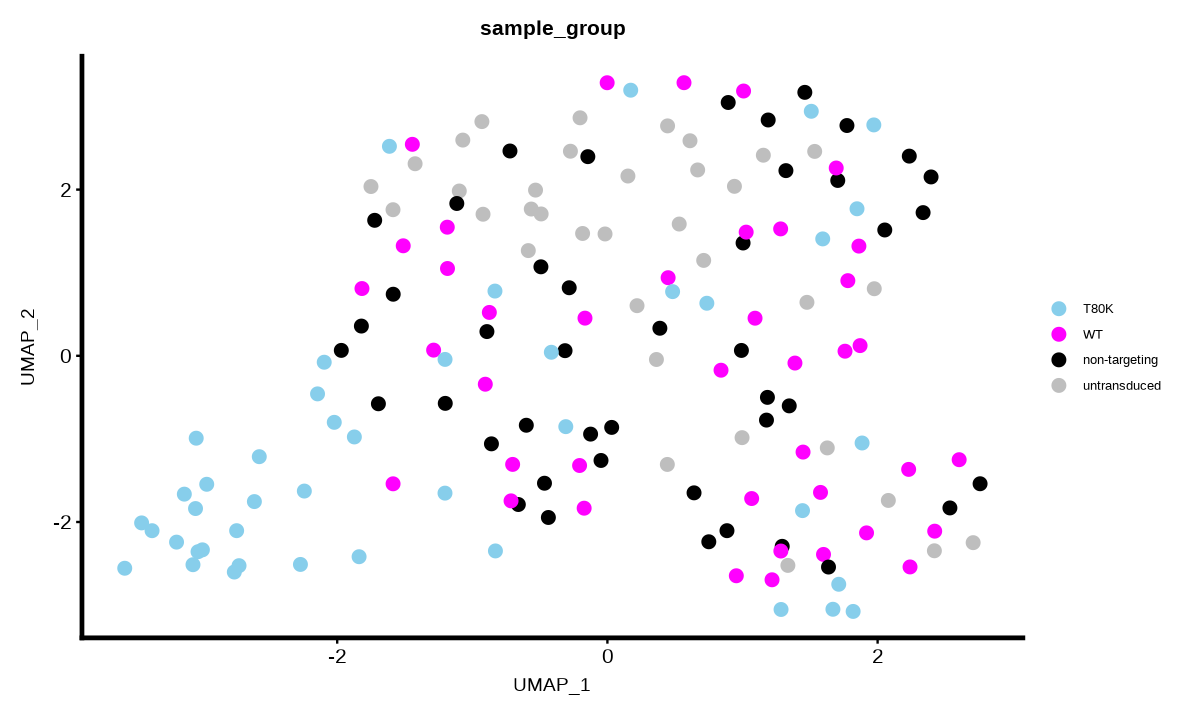

In [10]:
options(repr.plot.width = 10, repr.plot.height =6) 

adata <- RunUMAP(adata, dims = 1:10, reduction = "pca", reduction.name = "UMAP")
# visualize by batch and cell type annotation
publication_colors <- c(
 "sky blue",  
  "magenta",  
  "black",  
  "gray"  
)
p = DimPlot(adata, reduction = "UMAP", group.by = c("sample_group"), pt.size=3, cols = publication_colors) +
     theme(legend.text=element_text(size=9.5)) +
     theme(axis.line=element_line(size=1)) +
     theme(axis.text.x=element_text(size=16)) +
     theme(axis.text.y=element_text(size=16))
p

In [11]:
# Extract PCA coordinates
pc_df <- as.data.frame(Embeddings(adata, "pca")[, 1:5])
colnames(pc_df) <- paste0("PC", 1:5)
pc_df$sample_group <- adata$sample_group
pc_df$sample_group <- factor(pc_df$sample_group, levels = c("untransduced", "non-targeting", "WT", "T80K"))

In [12]:
# Calculate variance explained by each principal component
var_explained <- (adata[["pca"]]@stdev^2) /
                 sum(adata[["pca"]]@stdev^2) * 100

# Variance explained by PC1 and PC2
pc1_var <- sprintf("%.1f", var_explained[1])
pc2_var <- sprintf("%.1f", var_explained[2])

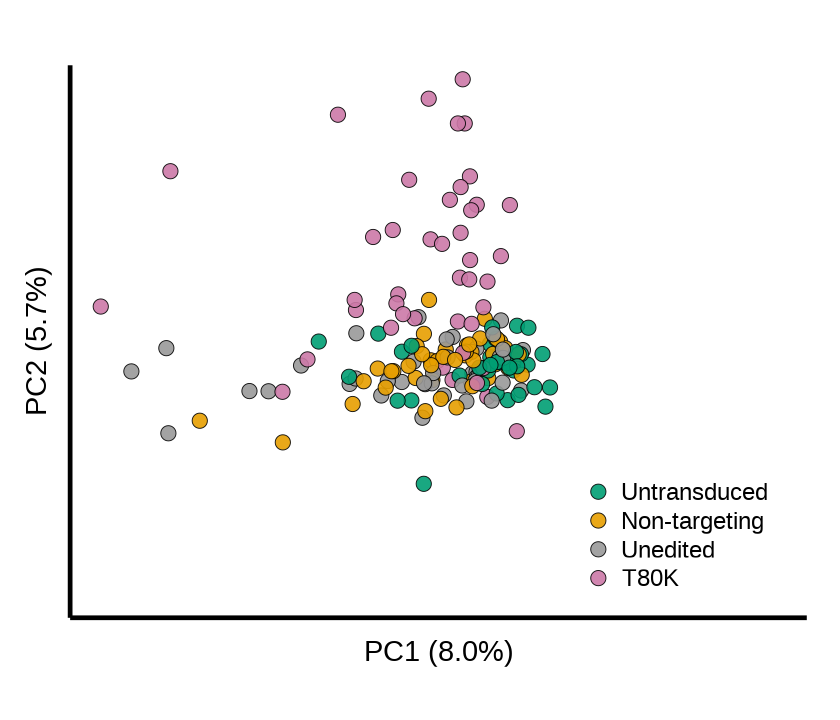

In [13]:
#plot PC1 x PC2
options(repr.plot.width = 7, repr.plot.height =6) 
ggplot(pc_df, aes(PC1, PC2, fill = sample_group)) +
  geom_point(size = 3.8, alpha = 0.9,
             shape = 21,
             color = "black",   # black border
             stroke = 0.3) +    # border thickness
  coord_equal(expand = FALSE) +
  theme_classic() +
  scale_fill_manual(values = c("untransduced" = "#009E73",   
                               "non-targeting" = "#E69F00",  
                               "WT" = "#999999",
                               "T80K" = "#CC79A7"
                              ),
                    labels = c("untransduced" = "Untransduced",   
                               "non-targeting" = "Non-targeting",  
                               "WT" = "Unedited"
                              )) +  
  labs(
    x = paste0("PC1 (", pc1_var, "%)"),
    y = paste0("PC2 (", pc2_var, "%)"),
  ) +
  theme(axis.title = element_blank(),
        axis.text = element_blank(),
        axis.ticks = element_blank(),
        axis.title.x = element_text(size = 22, vjust = -0.8, color = "black"),
        axis.title.y = element_text(size = 22, vjust = 2, color = "black"),
        axis.line = element_line(color = "black", size = 1),
        legend.position = "inside",
        legend.position.inside = c(0.85, 0.15),
        legend.background = element_rect(fill = "white", color = NA),
        legend.text = element_text(size = 18, color = "black"),
        legend.title = element_blank(),
        plot.margin = margin(10, 20, 10, 20)
        ) +
  xlim(-12,12) + 
  ylim(-9,9)

In [14]:
ggsave("data/PC_plot.pdf", plot = last_plot(), width = 7, height = 6)

In [15]:
#heatmap for PC2 top 20 genes
pc2_loadings <- Loadings(adata, "pca")[, 2]

# Sort by absolute loading to get top contributors
top_pc2_genes <- names(sort(abs(pc2_loadings), decreasing = TRUE))[1:20]

expr_mat <- as.matrix(GetAssayData(adata, slot = "scale.data")[top_pc2_genes, ])

#Column annotation
# Ensure the sample column is a factor with your desired order
annotation_col <- data.frame(Sample = factor(adata$sample_group, 
                                             levels = c("untransduced", "non-targeting", "WT", "T80K")))
rownames(annotation_col) <- colnames(expr_mat)

#cluster cells within each group
expr_mat_clustered <- do.call(cbind, lapply(split(seq_len(ncol(expr_mat)), annotation_col$Sample), function(idx){
  expr_mat[, idx][, order(hclust(dist(t(expr_mat[, idx])))$order)]
}))

annotation_col_clustered <- annotation_col[colnames(expr_mat_clustered), , drop = FALSE]


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


Loading required package: viridisLite



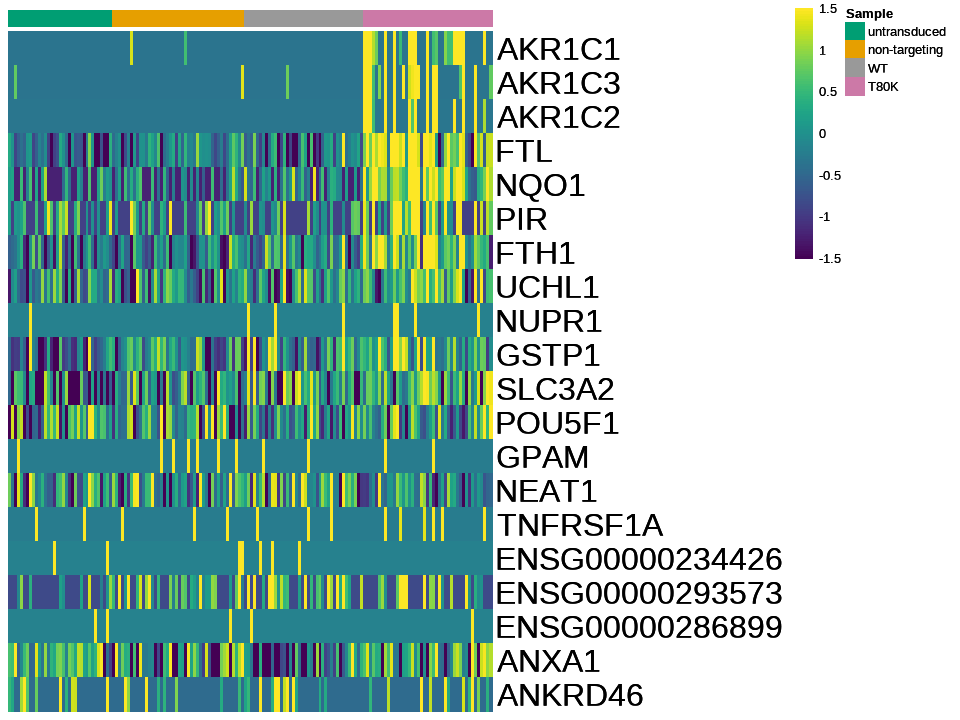

In [16]:
options(repr.plot.width = 8, repr.plot.height =6) 
library(pheatmap)
library(viridis)

# Stronger limits for z-scored expression
max_val <- 1.5
min_val <- -1.5
breaks <- seq(min_val, max_val, length.out = 101)

p = pheatmap(
  expr_mat_clustered,
  scale = "row",
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  show_rownames = TRUE,
  show_colnames = FALSE,
  annotation_col = annotation_col_clustered,
  annotation_names_col = FALSE,
  annotation_colors = list(
    Sample = c(
      "untransduced" = "#009E73",
      "non-targeting"   = "#E69F00",
      "WT"           = "#999999",
      "T80K"         = "#CC79A7"
    )
  ),
  color = viridis(100, option = "D"),  # Viridis diverging palette
  breaks = breaks,
  fontsize_row = 24,
  border_color = NA
)
p

In [17]:
save_pheatmap_pdf <- function(x, filename, width=16, height=12) {
  pdf(filename, width = width, height = height)
  grid::grid.newpage()
  grid::grid.draw(x$gtable)
  dev.off()
}
save_pheatmap_pdf(p, "data/pheatmap.pdf")

pdf 
  2

In [18]:
#box plots for PC1 to PC5
library(tidyr)

pc_long <- pivot_longer(
  pc_df,
  cols = starts_with("PC"),
  names_to = "PC",
  values_to = "score"
)

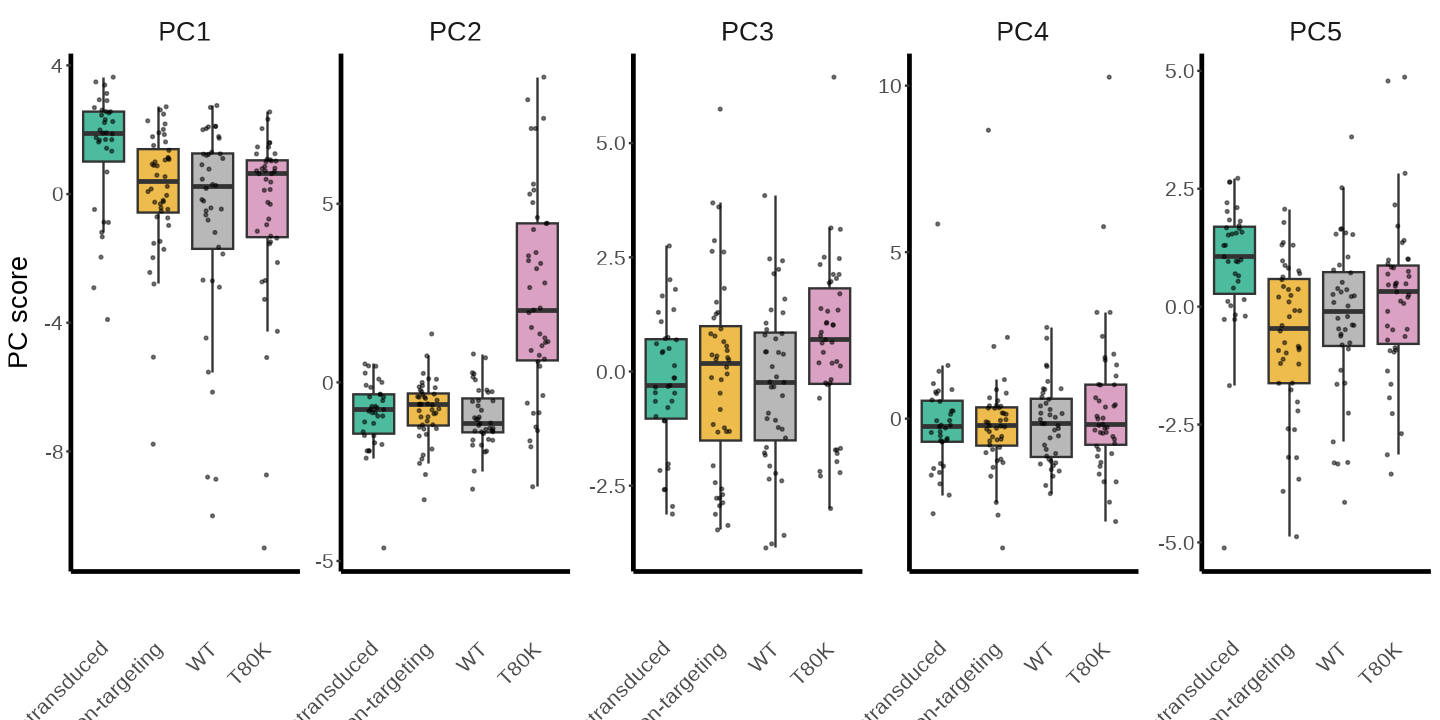

In [19]:
options(repr.plot.width = 12, repr.plot.height =6) 
ggplot(pc_long, aes(x = sample_group, y = score, fill = sample_group)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, size = 0.4, alpha = 0.5) +
  facet_wrap(~ PC, scales = "free_y", nrow = 1) +
  theme_classic() +
  labs(
    x = NULL,
    y = "PC score"
  ) +
  # Manually specify colors for each group
  scale_fill_manual(values = c("untransduced" = "#009E73",   
                               "non-targeting" = "#E69F00",  
                               "WT" = "#999999",
                               "T80K" = "#CC79A7"
                              )) +  
  theme(
    legend.position = "none",
    axis.text = element_text(size = 16),
    axis.text.x = element_text(angle = 45, vjust = 0.5, hjust = 1),
    axis.title.y = element_text(size = 20),
    axis.line = element_line(color = "black", size = 1),
    strip.text = element_text(size = 20),
    strip.background = element_blank(),
    axis.ticks.x = element_blank()
  )

In [20]:
ggsave("data/PC_box.pdf", plot = last_plot(), width = 12, height = 6)

In [21]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /software/cellgen/team205/si9/envs/Seurat/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] tidyr_1.3.1        viridis_0.6.5      viridisLite_0.4.2  pheatmap_1.0.13   
 [5] future_1.67.0      showtext_0.9-7     showtextdb_3.0     sysfonts_0.8.9    
 [9] dplyr_1.1.4        Seurat_5.3.0       SeuratObject_5.2.0 sp_2.2-0          
[13] stringr_1.5.2      ggplot2_3.5.2     

loaded via a namespace (a